INFINITE Quantum well

Dataset 'INFINITE_WELL_dataset.npz' successfully generated.

--- Starting Physics-Informed Training ---
Epoch  500 | Total Loss: 0.0048 | PDE Loss: 0.0044 | Norm Loss: 0.0004
Epoch 1000 | Total Loss: 0.0034 | PDE Loss: 0.0028 | Norm Loss: 0.0005
Epoch 1500 | Total Loss: 0.0053 | PDE Loss: 0.0053 | Norm Loss: 0.0000
Epoch 2000 | Total Loss: 0.0015 | PDE Loss: 0.0004 | Norm Loss: 0.0010

--- Training Complete. Evaluating Model ---


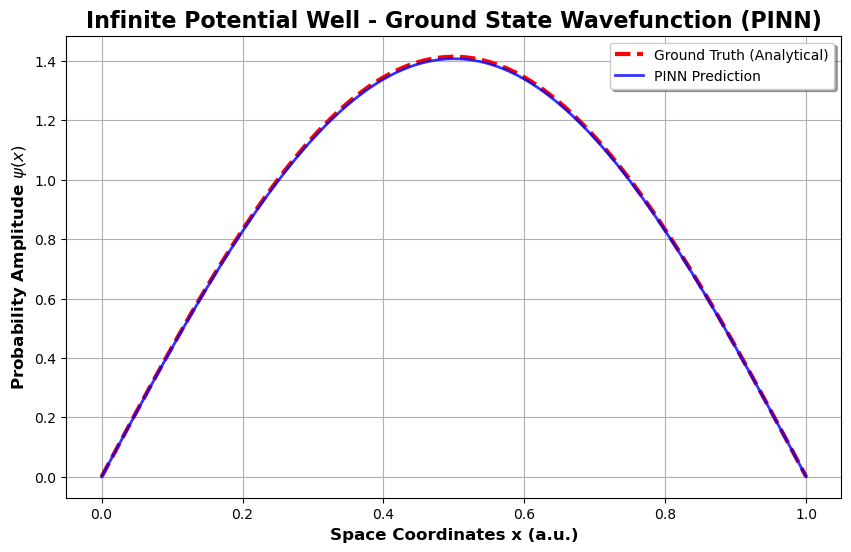

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================
# 1. TEST DATASET GENERATION
# ==============================================================
def generate_test_dataset(filename="INFINITE_WELL_dataset.npz"):
    """
    Generates the ground truth dataset for testing the PINN.
    The exact analytical ground state of the infinite square well 
    in domain [0, 1] is psi(x) = sqrt(2) * sin(pi * x).
    """
    if not os.path.exists(filename):
        x_data = np.linspace(0, 1, 200).reshape(-1, 1)
        psi_data = np.sqrt(2) * np.sin(np.pi * x_data)
        
        # Save as npz (same format used in your Jupyter Notebooks)
        np.savez(filename, x_data=x_data, psi_data=psi_data)
        print(f"Dataset '{filename}' successfully generated.\n")

# ==============================================================
# 2. PHYSICS-INFORMED NEURAL NETWORK MODEL
# ==============================================================
class PINN(nn.Module):
    def __init__(self, energy=np.pi**2):
        super(PINN, self).__init__()
        
        # Simple Multi-Layer Perceptron (MLP) architecture
        # We use Tanh as activation because it provides smooth, 
        # non-zero higher-order derivatives needed for PDEs.
        self.net = nn.Sequential(
            nn.Linear(1, 2),
            nn.Tanh(),
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 10),
            nn.Tanh(),
            nn.Linear(10, 1)  # Output node for probability amplitude
        )
        
        # The true ground-state energy is fixed for training
        self.E = energy
        
        # Optimizer and standard MSE criterion
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.005)
        self.criterion = nn.MSELoss()

    def forward(self, x):
        """
        Trial Wavefunction Ansatz: 
        Enforces Dirichlet boundary conditions psi(0) = psi(1) = 0 exactly.
        """
        # Trial function: x * (1-x) * NN(x)
        return x * (1.0 - x) * self.net(x)

    def diff_eq(self, x_colloc):
        """
        Computes the partial differential equation (PDE) residual 
        and the normalization constraint via automatic differentiation.
        """
        # Forward pass to calculate psi
        psi = self.forward(x_colloc)
        
        # First derivative: d(psi)/dx
        psi_x = torch.autograd.grad(
            outputs=psi, 
            inputs=x_colloc, 
            grad_outputs=torch.ones_like(psi), 
            create_graph=True
        )[0]
        
        # Second derivative: d^2(psi)/dx^2
        psi_xx = torch.autograd.grad(
            outputs=psi_x, 
            inputs=x_colloc, 
            grad_outputs=torch.ones_like(psi_x), 
            create_graph=True
        )[0]
        
        # Schrödinger Equation Residual: psi'' + E * psi = 0
        pde_res = psi_xx + self.E * psi
        
        # Normalization Constraint Approximation via Riemann Sum: mean(|psi|^2) * Length
        # (Since length is 1-0=1, the integral is just the mean)
        integral_approx = torch.mean(psi**2) 
        
        return pde_res, integral_approx

    def train_step(self, x_colloc):
        """
        Runs one step of optimization using physics-informed losses.
        """
        self.optimizer.zero_grad()
        
        # 1. Retrieve the PDE residual and integral approximation
        pde_res, integral_approx = self.diff_eq(x_colloc)
        
        # 2. Loss 1: Try to make the PDE residual 0 across all collocation points
        loss_pde = self.criterion(pde_res, torch.zeros_like(pde_res))
        
        # 3. Loss 2: Try to make the integral of probability amplitude squared equal 1
        loss_norm = (integral_approx - 1.0)**2
        
        # 4. Total Loss
        loss_total = loss_pde + loss_norm
        
        # Backpropagation
        loss_total.backward()
        self.optimizer.step()
        
        return loss_total.item(), loss_pde.item(), loss_norm.item()

# ==============================================================
# 3. MAIN TRAINING & EVALUATION LOOP
# ==============================================================
def main():
    # 1. Prepare testing dataset
    dataset_name = "INFINITE_WELL_dataset.npz"
    generate_test_dataset(dataset_name)
    
    # Load evaluation points and ground truth labels
    data = np.load(dataset_name)
    x_test = torch.tensor(data["x_data"], dtype=torch.float32)
    psi_test_true = data["psi_data"]

    # 2. Instantiate the Physics-Informed Neural Network
    net = PINN()
    
    # 3. Training Loop Configuration
    n_epochs = 2000
    batch_size = 500  # Random points generated per epoch
    
    print("--- Starting Physics-Informed Training ---")
    for epoch in range(n_epochs):
        # Randomly sample collocation points in the domain x in [0, 1]
        x_colloc = torch.rand(size=(batch_size, 1), requires_grad=True, dtype=torch.float32)
        
        # Run optimizer
        total_loss, pde_loss, norm_loss = net.train_step(x_colloc)
        
        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1:4d} | Total Loss: {total_loss:.4f} | PDE Loss: {pde_loss:.4f} | Norm Loss: {norm_loss:.4f}")

    # 4. Final Evaluation & Plotting
    print("\n--- Training Complete. Evaluating Model ---")
    
    with torch.no_grad():
        psi_pred = net(x_test).numpy()
    
    # Note: Eigenfunctions have an overall sign ambiguity (+psi or -psi both valid)
    # We enforce matching signs for a direct visual comparison with ground truth
    if np.sum(psi_pred) < 0:
        psi_pred = -psi_pred
        
    # Plotting Ground Truth against the PINN predictions
    plt.figure(figsize=(10, 6))
    plt.plot(x_test.numpy(), psi_test_true, 'r--', linewidth=3, label="Ground Truth (Analytical)")
    plt.plot(x_test.numpy(), psi_pred, 'b-', linewidth=2, alpha=0.8, label="PINN Prediction")
    
    plt.title("Infinite Potential Well - Ground State Wavefunction (PINN)", fontsize=16, weight='bold')
    plt.xlabel("Space Coordinates x (a.u.)", fontsize=12, weight='bold')
    plt.ylabel("Probability Amplitude $\psi(x)$", fontsize=12, weight='bold')
    plt.legend(loc='upper right', shadow=True)
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()

FINITE Quantum well

--- Starting PINN Training for Finite Well ---
Epoch  500 | Total Loss: 0.2894 | Learned Energy E: 1.1466
Epoch 1000 | Total Loss: 0.2115 | Learned Energy E: 1.2215
Epoch 1500 | Total Loss: 0.1627 | Learned Energy E: 1.3001
Epoch 2000 | Total Loss: 0.1467 | Learned Energy E: 1.3631
Epoch 2500 | Total Loss: 0.1370 | Learned Energy E: 1.3999
Epoch 3000 | Total Loss: 0.1380 | Learned Energy E: 1.4174
Epoch 3500 | Total Loss: 0.1124 | Learned Energy E: 1.4224
Epoch 4000 | Total Loss: 0.1194 | Learned Energy E: 1.4246
Epoch 4500 | Total Loss: 0.1757 | Learned Energy E: 1.4234
Epoch 5000 | Total Loss: 0.0991 | Learned Energy E: 1.4263
Epoch 5500 | Total Loss: 0.0810 | Learned Energy E: 1.4291
Epoch 6000 | Total Loss: 0.0809 | Learned Energy E: 1.4344
Epoch 6500 | Total Loss: 0.1199 | Learned Energy E: 1.4279
Epoch 7000 | Total Loss: 0.0632 | Learned Energy E: 1.4225
Epoch 7500 | Total Loss: 0.0469 | Learned Energy E: 1.4467
Epoch 8000 | Total Loss: 0.0725 | Learned Energy E: 1.4224
Epoch 850

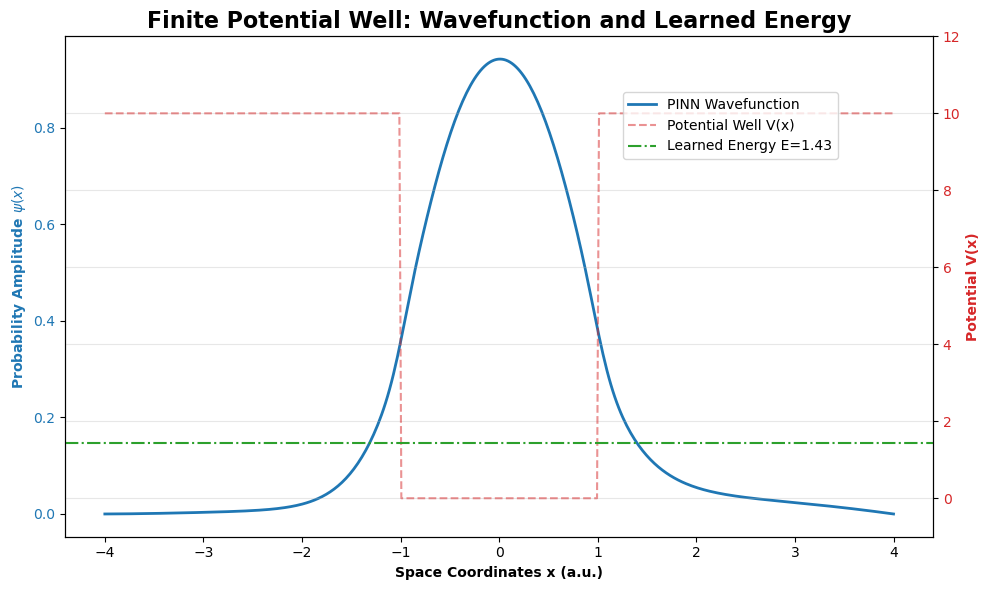

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
# PHYSICS-INFORMED NEURAL NETWORK: FINITE POTENTIAL WELL
# ==============================================================
class PINNFiniteWell(nn.Module):
    def __init__(self, L=4.0, V0=10.0, a=1.0):
        super(PINNFiniteWell, self).__init__()
        
        # Neural Network Architecture
        self.net = nn.Sequential(
            nn.Linear(1, 50),
            nn.Tanh(),
            nn.Linear(50, 25),
            nn.Tanh(),
            nn.Linear(25, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        )
        
        # Domain parameters
        self.L = L      # Truncated domain boundaries [-L, L]
        self.V0 = V0    # Potential barrier height
        self.a = a      # Well width is 2a (from -a to a)
        
        # --------------------------------------------------------
        # CRUCIAL: Energy E is now a TRAINABLE PARAMETER.
        # We initialize it with a guess (e.g., 1.0) and let the 
        # optimizer find the true eigenvalue during training.
        # --------------------------------------------------------
        self.E = nn.Parameter(torch.tensor([1.0], requires_grad=True))
        
        # The optimizer now updates both the NN weights AND the Energy parameter
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.005)
        self.criterion = nn.MSELoss()

    def forward(self, x):
        """
        Trial Wavefunction Ansatz: 
        Enforces Dirichlet boundary conditions at the truncated domain edges
        psi(-L) = psi(+L) = 0.
        """
        # Ansatz: (x - L) * (x + L) * NN(x)
        return (x - self.L) * (x + self.L) * self.net(x)

    def potential(self, x):
        """
        Defines the finite square well potential.
        V(x) = 0 if |x| < a, else V(x) = V0
        """
        # Using torch.where for tensor-compatible conditional logic
        return torch.where(torch.abs(x) < self.a, torch.tensor(0.0), torch.tensor(self.V0))

    def diff_eq(self, x_colloc):
        """
        Computes the PDE residual and the normalization constraint.
        """
        psi = self.forward(x_colloc)
        
        # Gradients for the PDE
        psi_x = torch.autograd.grad(
            outputs=psi, inputs=x_colloc, 
            grad_outputs=torch.ones_like(psi), create_graph=True
        )[0]
        
        psi_xx = torch.autograd.grad(
            outputs=psi_x, inputs=x_colloc, 
            grad_outputs=torch.ones_like(psi_x), create_graph=True
        )[0]
        
        # Get Potential V(x)
        V_x = self.potential(x_colloc)
        
        # Schrödinger Equation Residual: psi'' + (E - V) * psi = 0
        pde_res = psi_xx + (self.E - V_x) * psi
        
        # Normalization Constraint Approximation over domain [-L, L]
        # Integral length is 2*L. Riemann sum approximation.
        integral_approx = torch.mean(psi**2) * (2 * self.L)
        
        return pde_res, integral_approx

    def train_step(self, x_colloc):
        self.optimizer.zero_grad()
        
        pde_res, integral_approx = self.diff_eq(x_colloc)
        
        # PDE Loss and Normalization Loss
        loss_pde = self.criterion(pde_res, torch.zeros_like(pde_res))
        loss_norm = (integral_approx - 1.0)**2
        
        loss_total = loss_pde + loss_norm
        loss_total.backward()
        self.optimizer.step()
        
        return loss_total.item(), loss_pde.item(), loss_norm.item()

# ==============================================================
# MAIN TRAINING & EVALUATION LOOP
# ==============================================================
def main():
    # Model Setup
    L_domain = 4.0
    net = PINNFiniteWell(L=L_domain, V0=10.0, a=1.0)
    
    n_epochs = 10000
    batch_size = 600
    
    print("--- Starting PINN Training for Finite Well ---")
    for epoch in range(n_epochs):
        # Sample points uniformly in [-L, L]
        x_colloc = (2 * L_domain) * torch.rand(size=(batch_size, 1), requires_grad=True, dtype=torch.float32) - L_domain
        
        total_loss, pde_loss, norm_loss = net.train_step(x_colloc)
        
        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch+1:4d} | Total Loss: {total_loss:.4f} | Learned Energy E: {net.E.item():.4f}")

    # ==========================================
    # VISUALIZATION
    # ==========================================
    print("\n--- Training Complete ---")
    print(f"Final Estimated Ground State Energy: {net.E.item():.4f}")
    
    # Generate test points
    x_test = torch.tensor(np.linspace(-L_domain, L_domain, 400).reshape(-1, 1), dtype=torch.float32)
    
    with torch.no_grad():
        psi_pred = net(x_test).numpy()
        V_test = net.potential(x_test).numpy()
    
    # Align sign for visual aesthetics (make the peak positive)
    if psi_pred[200] < 0:  # center point index approx
        psi_pred = -psi_pred

    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Space Coordinates x (a.u.)', weight='bold')
    ax1.set_ylabel('Probability Amplitude $\psi(x)$', color=color, weight='bold')
    ax1.plot(x_test.numpy(), psi_pred, color=color, linewidth=2, label="PINN Wavefunction")
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Instantiate a second axes that shares the same x-axis to plot the potential
    ax2 = ax1.twinx()  
    color = 'tab:red'
    ax2.set_ylabel('Potential V(x)', color=color, weight='bold')  
    ax2.plot(x_test.numpy(), V_test, color=color, linestyle='--', alpha=0.5, label="Potential Well V(x)")
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.set_ylim(-1, 12) # Slightly larger than V0=10 for better visualization
    
    # Draw a line representing the learned energy level
    ax2.axhline(y=net.E.item(), color='tab:green', linestyle='-.', label=f'Learned Energy E={net.E.item():.2f}')

    plt.title("Finite Potential Well: Wavefunction and Learned Energy", fontsize=16, weight='bold')
    fig.tight_layout()
    fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    main()